# HFENN Regression - Random Split 对比实验

## 目的
验证使用 Random Split（与原始分类模型相同）时，回归模型是否也能达到高准确率。

## 关键区别
- **原始回归模型**: 使用 GroupShuffleSplit（按参与者分组，跨人验证）
- **本实验**: 使用 train_test_split（随机打散，存在数据泄露）

## ⚠️ 警告
Random Split 会导致同一参与者的数据同时出现在训练集和测试集，存在数据泄露风险。
此实验仅用于验证原始分类模型90%准确率是否因数据泄露导致。

---
**版本**: Random Split 对比实验
**日期**: 2025-01-03

In [1]:
# === Cell 1: 环境设置和导入 ===
import warnings
warnings.filterwarnings('ignore')

# 核心库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from datetime import datetime
import random

# 信号处理
from scipy.signal import find_peaks, hilbert, welch
from scipy.stats import skew, kurtosis
import pywt

# 机器学习
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split  # 使用Random Split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

# 深度学习
try:
    from keras import layers, models, Input, regularizers
    from keras.optimizers import Adam
    from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
    import keras.backend as K
    print("使用独立的 keras")
except ImportError:
    from tensorflow.keras import layers, models, Input, regularizers
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
    import tensorflow.keras.backend as K
    print("使用 tensorflow.keras")

# 设置随机种子
np.random.seed(42)
random.seed(42)

print("HFENN Regression (Random Split) 环境设置完成")
print(f"开始时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

使用独立的 keras
HFENN Regression (Random Split) 环境设置完成
开始时间: 2026-01-03 22:53:05


In [2]:
# === Cell 2: 加载数据 + 按参与者标准化 + 差分信号 ===
print("正在加载连续疲劳指数数据...")

# 读取所有参与者的连续数据
data_dir = 'data/processed'
all_files = glob.glob(os.path.join(data_dir, '*_continuous.csv'))

# 合并所有数据
df_list = []
for file in all_files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)
    print(f"  加载: {os.path.basename(file)} - {len(df_temp)} 行")

df = pd.concat(df_list, ignore_index=True)

# 数据清理
df.dropna(inplace=True)
df = df.reset_index(drop=True)

print(f"\n数据加载完成")
print(f"  数据形状: {df.shape}")
print(f"  参与者数量: {df['Participant_ID'].nunique()}")
print(f"  参与者列表: {df['Participant_ID'].unique().tolist()}")

# === 步骤一：按参与者Z-Score标准化 ===
print("\n[步骤一] 执行按参与者Z-Score标准化...")

def per_participant_standardization(df, columns):
    df_standardized = df.copy()
    for pid in df['Participant_ID'].unique():
        mask = df['Participant_ID'] == pid
        for col in columns:
            data = df.loc[mask, col].values
            mean_val = np.mean(data)
            std_val = np.std(data)
            if std_val > 0:
                df_standardized.loc[mask, col] = (data - mean_val) / std_val
            else:
                df_standardized.loc[mask, col] = 0
    return df_standardized

df = per_participant_standardization(df, ['Pulse', 'Fatigue'])
print(f"按参与者标准化完成")

# === 步骤二：增加差分信号 ===
print("\n[步骤二] 生成差分信号...")

def add_diff_signals(df):
    df_with_diff = df.copy()
    df_with_diff['Pulse_Diff'] = 0.0
    df_with_diff['Fatigue_Diff'] = 0.0
    for pid in df['Participant_ID'].unique():
        mask = df['Participant_ID'] == pid
        pulse_diff = df.loc[mask, 'Pulse'].diff().fillna(0)
        fatigue_diff = df.loc[mask, 'Fatigue'].diff().fillna(0)
        df_with_diff.loc[mask, 'Pulse_Diff'] = pulse_diff.values
        df_with_diff.loc[mask, 'Fatigue_Diff'] = fatigue_diff.values
    return df_with_diff

df = add_diff_signals(df)
print(f"差分信号生成完成")

正在加载连续疲劳指数数据...
  加载: all_participants_continuous.csv - 4144548 行
  加载: gs1_continuous.csv - 294177 行
  加载: gs2_continuous.csv - 362371 行
  加载: hww_continuous.csv - 346701 行
  加载: jz_continuous.csv - 286751 行
  加载: lx1_continuous.csv - 333634 行
  加载: lx2_continuous.csv - 312330 行
  加载: lx3_continuous.csv - 318714 行
  加载: pm_continuous.csv - 310307 行
  加载: ysp_continuous.csv - 258053 行
  加载: zch1_continuous.csv - 364557 行
  加载: zch2_continuous.csv - 303580 行
  加载: zm_continuous.csv - 359880 行
  加载: zxl_continuous.csv - 293493 行

数据加载完成
  数据形状: (8289096, 8)
  参与者数量: 13
  参与者列表: ['gs1', 'gs2', 'hww', 'jz', 'lx1', 'lx2', 'lx3', 'pm', 'ysp', 'zch1', 'zch2', 'zm', 'zxl']

[步骤一] 执行按参与者Z-Score标准化...
按参与者标准化完成

[步骤二] 生成差分信号...
差分信号生成完成


In [3]:
# === Cell 3: 四通道特征提取器 ===
print("构建四通道特征提取器...")

class QuadChannelFeatureExtractor:
    def __init__(self, sampling_rate=87):
        self.sampling_rate = sampling_rate
        
    def extract_time_domain_features(self, signal):
        features = []
        features.extend([
            np.mean(signal), np.std(signal), np.max(signal), np.min(signal),
            np.median(signal), skew(signal), kurtosis(signal), np.var(signal),
            np.ptp(signal), np.percentile(signal, 25), np.percentile(signal, 75),
            len(find_peaks(signal)[0]), len(find_peaks(-signal)[0]),
            np.sum(signal**2), np.mean(signal**2), np.sqrt(np.mean(signal**2)),
        ])
        return features
    
    def extract_frequency_domain_features(self, signal):
        features = []
        freqs, psd = welch(signal, fs=self.sampling_rate, nperseg=min(256, len(signal)//4))
        features.extend([np.mean(psd), np.std(psd), np.max(psd),
                        freqs[np.argmax(psd)] if len(psd) > 0 else 0, np.sum(psd)])
        freq_bands = [(0, 1), (1, 5), (5, 15), (15, 25)]
        total_power = np.sum(psd)
        for low, high in freq_bands:
            band_mask = (freqs >= low) & (freqs <= high)
            band_power = np.sum(psd[band_mask])
            features.append(band_power / total_power if total_power > 0 else 0)
        return features
    
    def extract_wavelet_features(self, signal):
        features = []
        coeffs = pywt.wavedec(signal, 'db4', level=4)
        for coeff in coeffs:
            if len(coeff) > 0:
                features.extend([np.mean(coeff), np.std(coeff), np.sum(coeff**2), np.max(np.abs(coeff))])
        return features
    
    def extract_nonlinear_features(self, signal):
        features = []
        analytic_signal = hilbert(signal)
        amplitude_envelope = np.abs(analytic_signal)
        instantaneous_phase = np.angle(analytic_signal)
        features.extend([np.mean(amplitude_envelope), np.std(amplitude_envelope),
                        np.mean(np.diff(instantaneous_phase))])
        zero_crossings = np.sum(np.diff(np.sign(signal - np.mean(signal))) != 0) / len(signal)
        features.append(zero_crossings)
        return features
    
    def extract_diff_features(self, diff_signal):
        features = []
        features.extend([
            np.mean(diff_signal), np.std(diff_signal), np.max(diff_signal), np.min(diff_signal),
            np.sum(diff_signal > 0) / len(diff_signal), np.sum(diff_signal < 0) / len(diff_signal),
            np.sum(np.abs(diff_signal)), np.mean(np.abs(diff_signal)),
            skew(diff_signal), kurtosis(diff_signal),
        ])
        return features
    
    def extract_single_channel_features(self, signal):
        all_features = []
        all_features.extend(self.extract_time_domain_features(signal))
        all_features.extend(self.extract_frequency_domain_features(signal))
        all_features.extend(self.extract_wavelet_features(signal))
        all_features.extend(self.extract_nonlinear_features(signal))
        return np.array(all_features)
    
    def extract_quad_channel_features(self, pulse, fatigue, pulse_diff, fatigue_diff):
        pulse_features = self.extract_single_channel_features(pulse)
        fatigue_features = self.extract_single_channel_features(fatigue)
        pulse_diff_features = self.extract_diff_features(pulse_diff)
        fatigue_diff_features = self.extract_diff_features(fatigue_diff)
        return np.concatenate([pulse_features, fatigue_features, pulse_diff_features, fatigue_diff_features])

feature_extractor = QuadChannelFeatureExtractor()
print(f"四通道特征提取器构建完成")

构建四通道特征提取器...
四通道特征提取器构建完成


In [4]:
# === Cell 4: 数据分段和特征提取 ===
print("开始数据分段和特征提取...")

def extract_regression_segments(df, window_size=2610, overlap_ratio=0.5):
    step = int(window_size * (1 - overlap_ratio))
    pulse_segments, fatigue_segments, enhanced_features = [], [], []
    target_values, participant_ids, segment_indices = [], [], []
    
    for pid in df['Participant_ID'].unique():
        df_p = df[df['Participant_ID'] == pid].reset_index(drop=True)
        pulse_data = df_p['Pulse'].values
        fatigue_data = df_p['Fatigue'].values
        pulse_diff_data = df_p['Pulse_Diff'].values
        fatigue_diff_data = df_p['Fatigue_Diff'].values
        target_data = df_p['Fatigue_Score_Smoothed'].values
        
        seg_idx = 0
        for start in range(0, len(pulse_data) - window_size + 1, step):
            end = start + window_size
            pulse_seg = pulse_data[start:end]
            fatigue_seg = fatigue_data[start:end]
            pulse_diff_seg = pulse_diff_data[start:end]
            fatigue_diff_seg = fatigue_diff_data[start:end]
            target_seg = target_data[start:end]
            
            pulse_segments.append(pulse_seg)
            fatigue_segments.append(fatigue_seg)
            features = feature_extractor.extract_quad_channel_features(
                pulse_seg, fatigue_seg, pulse_diff_seg, fatigue_diff_seg)
            enhanced_features.append(features)
            target_values.append(target_seg[-1])
            participant_ids.append(pid)
            segment_indices.append(seg_idx)
            seg_idx += 1
    
    return (np.array(pulse_segments), np.array(fatigue_segments), 
            np.array(enhanced_features), np.array(target_values), 
            np.array(participant_ids), np.array(segment_indices))

pulse_ts, fatigue_ts, features, targets, pids, seg_indices = extract_regression_segments(df)
features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

print(f"数据分段完成:")
print(f"  样本数: {len(targets)}")
print(f"  特征数: {features.shape[1]}")

# 特征平滑
def apply_feature_smoothing(features, pids, seg_indices, window_size=3):
    features_smoothed = features.copy()
    for pid in np.unique(pids):
        pid_mask = pids == pid
        pid_indices = np.where(pid_mask)[0]
        sorted_order = np.argsort(seg_indices[pid_mask])
        sorted_indices = pid_indices[sorted_order]
        pid_features = features[sorted_indices]
        n_samples = len(pid_features)
        if n_samples >= window_size:
            df_features = pd.DataFrame(pid_features)
            smoothed = df_features.rolling(window=window_size, min_periods=1, center=True).mean().values
            for i, orig_idx in enumerate(sorted_indices):
                features_smoothed[orig_idx] = smoothed[i]
    return features_smoothed

features = apply_feature_smoothing(features, pids, seg_indices, window_size=3)
print(f"特征平滑完成")

开始数据分段和特征提取...
数据分段完成:
  样本数: 6332
  特征数: 118
特征平滑完成


In [5]:
# === Cell 5: 数据分割（Random Split - 与原始分类模型相同）===
# ⚠️ 关键区别：使用 train_test_split 而非 GroupShuffleSplit
print("="*60)
print("⚠️ 使用 Random Split（与原始HFENN分类模型相同）")
print("⚠️ 警告：此方式存在数据泄露，仅用于对比实验")
print("="*60)

# 特征标准化和选择
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
n_features = min(50, features.shape[1])
selector = SelectKBest(score_func=f_regression, k=n_features)
features_selected = selector.fit_transform(features_scaled, targets)

# 准备数据
X_pulse = pulse_ts.reshape(pulse_ts.shape[0], pulse_ts.shape[1], 1)
X_fatigue = fatigue_ts.reshape(fatigue_ts.shape[0], fatigue_ts.shape[1], 1)
X_features = features_selected
y = targets

# === 关键：使用 Random Split（与原始分类模型相同）===
X_pulse_train, X_pulse_test, X_fatigue_train, X_fatigue_test, X_feat_train, X_feat_test, y_train, y_test, pids_train, pids_test = train_test_split(
    X_pulse, X_fatigue, X_features, y, pids,
    test_size=0.2, random_state=42
)

print(f"\n数据分割完成（Random Split）:")
print(f"  训练集: {len(y_train)} 样本")
print(f"  测试集: {len(y_test)} 样本")
print(f"  训练集参与者: {np.unique(pids_train).tolist()}")
print(f"  测试集参与者: {np.unique(pids_test).tolist()}")
print(f"\n⚠️ 注意：训练集和测试集包含相同参与者的数据（数据泄露）")

⚠️ 使用 Random Split（与原始HFENN分类模型相同）
⚠️ 警告：此方式存在数据泄露，仅用于对比实验

数据分割完成（Random Split）:
  训练集: 5065 样本
  测试集: 1267 样本
  训练集参与者: ['gs1', 'gs2', 'hww', 'jz', 'lx1', 'lx2', 'lx3', 'pm', 'ysp', 'zch1', 'zch2', 'zm', 'zxl']
  测试集参与者: ['gs1', 'gs2', 'hww', 'jz', 'lx1', 'lx2', 'lx3', 'pm', 'ysp', 'zch1', 'zch2', 'zm', 'zxl']

⚠️ 注意：训练集和测试集包含相同参与者的数据（数据泄露）


In [6]:
# === Cell 6: 双通道小波变换 ===
print("执行双通道小波变换...")

def wavelet_transform_batch(data, wavelet='db4', level=4):
    n_samples = data.shape[0]
    sample_coeffs = pywt.wavedec(data[0, :, 0], wavelet, level=level)
    coeff_lengths = [len(c) for c in sample_coeffs]
    all_coeffs = [np.zeros((n_samples, length, 1)) for length in coeff_lengths]
    for i in range(n_samples):
        signal = data[i, :, 0]
        coeffs = pywt.wavedec(signal, wavelet, level=level)
        for j, coeff in enumerate(coeffs):
            all_coeffs[j][i, :, 0] = coeff
    return all_coeffs

# Pulse通道
pulse_train_coeffs = wavelet_transform_batch(X_pulse_train)
pulse_cA4_train, pulse_cD4_train, pulse_cD3_train, pulse_cD2_train, pulse_cD1_train = pulse_train_coeffs
pulse_test_coeffs = wavelet_transform_batch(X_pulse_test)
pulse_cA4_test, pulse_cD4_test, pulse_cD3_test, pulse_cD2_test, pulse_cD1_test = pulse_test_coeffs

# Fatigue通道
fatigue_train_coeffs = wavelet_transform_batch(X_fatigue_train)
fatigue_cA4_train, fatigue_cD4_train, fatigue_cD3_train, fatigue_cD2_train, fatigue_cD1_train = fatigue_train_coeffs
fatigue_test_coeffs = wavelet_transform_batch(X_fatigue_test)
fatigue_cA4_test, fatigue_cD4_test, fatigue_cD3_test, fatigue_cD2_test, fatigue_cD1_test = fatigue_test_coeffs

print(f"小波变换完成")

执行双通道小波变换...
小波变换完成


In [7]:
# === Cell 7: 构建模型 ===
print("构建双通道HFENN回归模型...")

def attention_block(x, filters):
    attention = layers.Dense(filters, activation='tanh')(x)
    attention = layers.Dense(filters, activation='softmax')(attention)
    attended = layers.Multiply()([x, attention])
    return attended

def residual_block(x, filters, kernel_size=3, dropout_rate=0.3):
    shortcut = x
    x = layers.Conv1D(filters, kernel_size, padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Conv1D(filters, kernel_size, padding='same', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, shortcut])
    x = layers.ReLU()(x)
    x = attention_block(x, filters)
    return x

def build_wavelet_branch(input_shapes, prefix, filters=32, dropout_rate=0.3):
    inputs, outputs = [], []
    for i, (name, shape) in enumerate(input_shapes):
        inp = Input(shape=shape, name=f'{prefix}_{name}_input')
        inputs.append(inp)
        x = residual_block(inp, filters, dropout_rate=dropout_rate)
        x = layers.GlobalMaxPooling1D()(x)
        outputs.append(x)
    merged = layers.Concatenate(name=f'{prefix}_wavelet_merge')(outputs)
    return inputs, merged

# Pulse通道
pulse_shapes = [('cA4', pulse_cA4_train.shape[1:]), ('cD4', pulse_cD4_train.shape[1:]),
               ('cD3', pulse_cD3_train.shape[1:]), ('cD2', pulse_cD2_train.shape[1:]),
               ('cD1', pulse_cD1_train.shape[1:])]
pulse_inputs, pulse_features = build_wavelet_branch(pulse_shapes, 'pulse')

# Fatigue通道
fatigue_shapes = [('cA4', fatigue_cA4_train.shape[1:]), ('cD4', fatigue_cD4_train.shape[1:]),
                 ('cD3', fatigue_cD3_train.shape[1:]), ('cD2', fatigue_cD2_train.shape[1:]),
                 ('cD1', fatigue_cD1_train.shape[1:])]
fatigue_inputs, fatigue_features = build_wavelet_branch(fatigue_shapes, 'fatigue')

# 合并
dual_wavelet_features = layers.Concatenate()([pulse_features, fatigue_features])

# 增强特征
input_enhanced = Input(shape=X_feat_train.shape[1:], name='enhanced_features_input')
enhanced_branch = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(input_enhanced)
enhanced_branch = layers.BatchNormalization()(enhanced_branch)
enhanced_branch = layers.Dropout(0.5)(enhanced_branch)
enhanced_branch = layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(enhanced_branch)

# 融合
fused = layers.Concatenate()([dual_wavelet_features, enhanced_branch])
x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(fused)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(1, activation='sigmoid', name='regression_output')(x)

all_inputs = pulse_inputs + fatigue_inputs + [input_enhanced]
model = models.Model(inputs=all_inputs, outputs=output, name='HFENN_Regression_RandomSplit')
print(f"模型构建完成! 参数: {model.count_params():,}")

构建双通道HFENN回归模型...
模型构建完成! 参数: 115,873


In [8]:
# === Cell 8: 编译和训练 ===
print("配置训练...")

try:
    from keras import ops
    def rmse(y_true, y_pred):
        return ops.sqrt(ops.mean(ops.square(y_pred - y_true)))
    def r2_metric(y_true, y_pred):
        ss_res = ops.sum(ops.square(y_true - y_pred))
        ss_tot = ops.sum(ops.square(y_true - ops.mean(y_true)))
        return 1 - ss_res / (ss_tot + 1e-7)
except ImportError:
    import tensorflow as tf
    def rmse(y_true, y_pred):
        return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))
    def r2_metric(y_true, y_pred):
        ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
        ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
        return 1 - ss_res / (ss_tot + 1e-7)

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae', rmse, r2_metric])

callbacks_list = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ModelCheckpoint('HFENN_Regression_RandomSplit_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

train_inputs = [pulse_cA4_train, pulse_cD4_train, pulse_cD3_train, pulse_cD2_train, pulse_cD1_train,
               fatigue_cA4_train, fatigue_cD4_train, fatigue_cD3_train, fatigue_cD2_train, fatigue_cD1_train,
               X_feat_train]
test_inputs = [pulse_cA4_test, pulse_cD4_test, pulse_cD3_test, pulse_cD2_test, pulse_cD1_test,
              fatigue_cA4_test, fatigue_cD4_test, fatigue_cD3_test, fatigue_cD2_test, fatigue_cD1_test,
              X_feat_test]

print(f"开始训练...")
history = model.fit(train_inputs, y_train, validation_data=(test_inputs, y_test),
                   epochs=100, batch_size=32, callbacks=callbacks_list, verbose=1)
print(f"训练完成!")

配置训练...
开始训练...
Epoch 1/100
158/159 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 4.9695 - mae: 0.2404 - r2_metric: -74.3028 - rmse: 0.4471
Epoch 1: val_loss improved from inf to 1.39606, saving model to HFENN_Regression_RandomSplit_best.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - loss: 4.9503 - mae: 0.2400 - r2_metric: -74.2832 - rmse: 0.4471 - val_loss: 1.3961 - val_mae: 0.2031 - val_r2_metric: -39.9829 - val_rmse: 0.3307 - learning_rate: 0.0010
Epoch 2/100
158/159 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 1.0567 - mae: 0.1815 - r2_metric: -66.6597 - rmse: 0.4233
Epoch 2: val_loss improved from 1.39606 to 0.45262, saving model to HFENN_Regression_RandomSplit_best.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 1.0536 - mae: 0.1815 - r2_metric: -66.6424 - rmse: 0.4232 - val_loss: 0.4526 - val_mae: 0.2189 - val_r2_metric: -35.5450 - val_rmse: 0.3125 - learning_rate: 0.0010
Epoch 3/100
158/159 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.3559 - mae: 0.1728 - r2_metric: -62.89

In [9]:
# === Cell 9: 评估（回归 + 分类转换）===
print("="*60)
print("HFENN回归模型评估（Random Split）")
print("="*60)

y_pred = model.predict(test_inputs).flatten()

# 回归指标
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse_val = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n回归性能指标:")
print(f"  MSE:  {mse:.6f}")
print(f"  MAE:  {mae:.6f}")
print(f"  RMSE: {rmse_val:.6f}")
print(f"  R2:   {r2:.4f}")

# 分类转换评估
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

def discretize_fatigue(scores, thresholds):
    labels = np.zeros_like(scores, dtype=int)
    labels[(scores >= thresholds[0]) & (scores < thresholds[1])] = 1
    labels[scores >= thresholds[1]] = 2
    return labels

# 使用原始阈值
thresholds = (0.35, 0.75)
y_test_class = discretize_fatigue(y_test, thresholds)
y_pred_class = discretize_fatigue(y_pred, thresholds)

accuracy = accuracy_score(y_test_class, y_pred_class)
cm = confusion_matrix(y_test_class, y_pred_class)

print(f"\n分类转换评估（阈值: {thresholds}）:")
print(f"  准确率: {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\n混淆矩阵:")
print(f"              Pred_Normal  Pred_Mild  Pred_Severe")
print(f"  True_Normal     {cm[0,0]:5d}      {cm[0,1]:5d}       {cm[0,2]:5d}")
print(f"  True_Mild       {cm[1,0]:5d}      {cm[1,1]:5d}       {cm[1,2]:5d}")
print(f"  True_Severe     {cm[2,0]:5d}      {cm[2,1]:5d}       {cm[2,2]:5d}")

adjacent_errors = cm[0,1] + cm[1,0] + cm[1,2] + cm[2,1]
non_adjacent_errors = cm[0,2] + cm[2,0]
total_errors = np.sum(cm) - np.trace(cm)

print(f"\n错误分析:")
print(f"  总错误数: {total_errors}")
print(f"  相邻等级错误: {adjacent_errors} ({adjacent_errors/max(total_errors,1)*100:.1f}%)")
print(f"  跨级错误: {non_adjacent_errors} ({non_adjacent_errors/max(total_errors,1)*100:.1f}%)")

print(f"\n分类报告:")
print(classification_report(y_test_class, y_pred_class, 
                           target_names=['Normal', 'Mild Fatigue', 'Severe Fatigue'], digits=4))

HFENN回归模型评估（Random Split）
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

回归性能指标:
  MSE:  0.011895
  MAE:  0.082474
  RMSE: 0.109062
  R2:   0.8660

分类转换评估（阈值: (0.35, 0.75)）:
  准确率: 0.8595 (85.95%)

混淆矩阵:
              Pred_Normal  Pred_Mild  Pred_Severe
  True_Normal       414         62           1
  True_Mild          31        377          57
  True_Severe         0         27         298

错误分析:
  总错误数: 178
  相邻等级错误: 177 (99.4%)
  跨级错误: 1 (0.6%)

分类报告:
                precision    recall  f1-score   support

        Normal     0.9303    0.8679    0.8980       477
  Mild Fatigue     0.8090    0.8108    0.8099       465
Severe Fatigue     0.8371    0.9169    0.8752       325

      accuracy                         0.8595      1267
     macro avg     0.8588    0.8652    0.8610      1267
  weighted avg     0.8619    0.8595    0.8598      1267



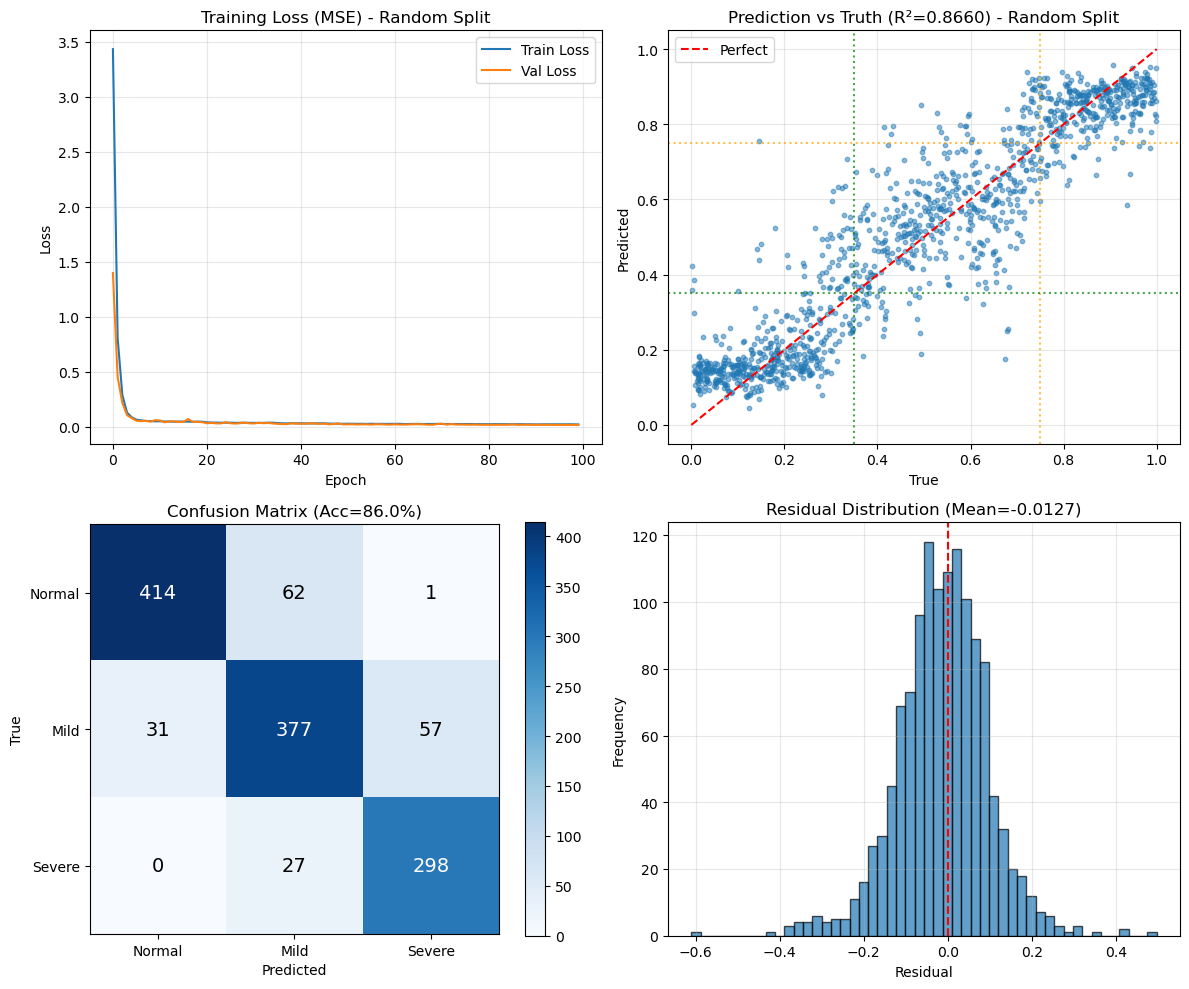


结果已保存: HFENN_Regression_RandomSplit_Results.png


In [10]:
# === Cell 10: 可视化 ===
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Loss曲线
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Training Loss (MSE) - Random Split')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 预测vs真实
axes[0, 1].scatter(y_test, y_pred, alpha=0.5, s=10)
axes[0, 1].plot([0, 1], [0, 1], 'r--', label='Perfect')
axes[0, 1].axvline(x=0.35, color='g', linestyle=':', alpha=0.7)
axes[0, 1].axvline(x=0.75, color='orange', linestyle=':', alpha=0.7)
axes[0, 1].axhline(y=0.35, color='g', linestyle=':', alpha=0.7)
axes[0, 1].axhline(y=0.75, color='orange', linestyle=':', alpha=0.7)
axes[0, 1].set_title(f'Prediction vs Truth (R²={r2:.4f}) - Random Split')
axes[0, 1].set_xlabel('True')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 混淆矩阵
im = axes[1, 0].imshow(cm, cmap=plt.cm.Blues)
axes[1, 0].set_title(f'Confusion Matrix (Acc={accuracy*100:.1f}%)')
axes[1, 0].set_xticks([0, 1, 2])
axes[1, 0].set_yticks([0, 1, 2])
axes[1, 0].set_xticklabels(['Normal', 'Mild', 'Severe'])
axes[1, 0].set_yticklabels(['Normal', 'Mild', 'Severe'])
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')
for i in range(3):
    for j in range(3):
        text_color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        axes[1, 0].text(j, i, str(cm[i, j]), ha='center', va='center', color=text_color, fontsize=14)
plt.colorbar(im, ax=axes[1, 0])

# 残差
residuals = y_test - y_pred
axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_title(f'Residual Distribution (Mean={np.mean(residuals):.4f})')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('HFENN_Regression_RandomSplit_Results.png', dpi=150)
plt.show()

print(f"\n结果已保存: HFENN_Regression_RandomSplit_Results.png")

In [11]:
# === Cell 11: 结果对比总结 ===
print("="*60)
print("实验结论")
print("="*60)
print(f"\n本实验使用 Random Split（与原始HFENN分类模型相同）")
print(f"\n回归性能:")
print(f"  R² = {r2:.4f}")
print(f"\n分类转换性能（阈值 0.35, 0.75）:")
print(f"  准确率 = {accuracy*100:.2f}%")
print(f"\n对比:")
print(f"  - 原始HFENN分类模型（Random Split）: ~90% 准确率")
print(f"  - 回归模型（跨人验证 LOSO）: ~57% 准确率")
print(f"  - 回归模型（Random Split）: {accuracy*100:.2f}% 准确率")
print(f"\n如果 Random Split 下回归模型也能达到高准确率，")
print(f"则证明原始分类模型的90%准确率是因为数据泄露导致的虚高。")

实验结论

本实验使用 Random Split（与原始HFENN分类模型相同）

回归性能:
  R² = 0.8660

分类转换性能（阈值 0.35, 0.75）:
  准确率 = 85.95%

对比:
  - 原始HFENN分类模型（Random Split）: ~90% 准确率
  - 回归模型（跨人验证 LOSO）: ~57% 准确率
  - 回归模型（Random Split）: 85.95% 准确率

如果 Random Split 下回归模型也能达到高准确率，
则证明原始分类模型的90%准确率是因为数据泄露导致的虚高。
